# 1. Exploratory Data Analysis (EDA)

This notebook contains exploratory data analysis of the MovieLens 32M dataset.

## 1.1. Importing Libraries and Loading Paths

In [2]:
import json
import urllib
import zipfile
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from mrh.utils import load_json
from mrh.data import download_data, extract_archive

C:\something\aie\aie-shishova\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path.cwd().parent
paths_path = PROJECT_ROOT / 'configs/paths.json'

paths = load_json(paths_path)

## 1.2. Downloading and Extracting Data

In [4]:
data_url = paths['data_url']
data_dir = PROJECT_ROOT / paths['data_dir']
data_raw_dir = PROJECT_ROOT / paths['data_raw_dir']
ml_32m_zip = data_raw_dir / paths['ml_32m_zip']
download_data(url=data_url, path=ml_32m_zip)

In [5]:
ml_32m = data_raw_dir / paths['ml_32m']
extract_archive(path_from=ml_32m_zip, directory=data_raw_dir, expected_path=ml_32m)

## 1.3. Analysis of ratings.csv, movies.csv and tags.csv Files

In [6]:
ratings_path = ml_32m / paths['ratings_path']
movies_path = ml_32m / paths['movies_path']
tags_path = ml_32m / paths['tags_path']

In [7]:
def analyse_df_by_path(df_path):
    """
    General analysis of a csv file.
    Outputs:
        - first five rows;
        - last five rows;
        - shape;
        - description of numeric columns;
        - number of missing values;
        - number of duplicates.
    """
    if not str(df_path).lower().endswith('.csv'):
        print(f'Warning: file "{df_path}" does not have a .csv extension')
    
    if not Path(df_path).exists():
        print(f'Error: file "{df_path}" not found!')
        return None
    
    print('Path:', df_path)
    
    try:
        df = pd.read_csv(df_path)
    except Exception as e:
        print(f'Loading error: {e}')
        return None
    
    print()
    print('First five rows:')
    display(df.head())
    print('\nLast five rows:')
    display(df.tail())
    print(f'\nShape: {df.shape}')
    print('\nDescription:')
    display(df.describe())
    print(f'\nNumber of missing values: {np.sum(df.isnull())}')
    print(f'\nNumber of duplicates: {np.sum(df.duplicated())}\n\n')
    return df

In [8]:
ratings = analyse_df_by_path(ratings_path)

Path: C:\something\my-projects\movie-recsys-hybrid\data\raw\ml-32m\ratings.csv

First five rows:


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858



Last five rows:


,userId,movieId,rating,timestamp
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800
32000203,200948,87304,4.5,1350423523



Shape: (32000204, 4)

Description:


,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09



Number of missing values: 0

Number of duplicates: 0




In [9]:
movies = analyse_df_by_path(movies_path)

Path: C:\something\my-projects\movie-recsys-hybrid\data\raw\ml-32m\movies.csv

First five rows:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Last five rows:


,movieId,title,genres
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama
87584,292757,Race to the Summit (2023),Action|Adventure|Documentary



Shape: (87585, 3)

Description:


,movieId
count,87585.000000
mean,157651.365519
std,79013.402099
min,1.000000
25%,112657.000000
50%,165741.000000
75%,213203.000000
max,292757.000000



Number of missing values: 0

Number of duplicates: 0




In [10]:
tags = analyse_df_by_path(tags_path)

Path: C:\something\my-projects\movie-recsys-hybrid\data\raw\ml-32m\tags.csv

First five rows:


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102



Last five rows:


,userId,movieId,tag,timestamp
2000067,162279,90645,Rafe Spall,1320817734
2000068,162279,91079,Anton Yelchin,1322337407
2000069,162279,91079,Felicity Jones,1322337400
2000070,162279,91658,Rooney Mara,1325828398
2000071,162279,100714,Julie Delpy,1373095449



Shape: (2000072, 4)

Description:


,userId,movieId,timestamp
count,2.000072e+06,2.000072e+06,2.000072e+06
mean,8.192859e+04,7.189326e+04,1.528914e+09
std,3.810650e+04,7.480379e+04,1.290835e+08
min,2.200000e+01,1.000000e+00,1.135429e+09
25%,6.841300e+04,4.011000e+03,1.473615e+09
50%,7.821300e+04,5.232800e+04,1.574071e+09
75%,1.036980e+05,1.222940e+05,1.614740e+09
max,1.622790e+05,2.926290e+05,1.697155e+09



Number of missing values: 17

Number of duplicates: 0




In [11]:
tags[tags.isna().any(axis=1)]

,userId,movieId,tag,timestamp
185377,27046,33826,NaN,1221450908
1394089,89369,281500,NaN,1670942104
1914668,153443,123,NaN,1199450867
1914669,153443,346,NaN,1199451946
1914673,153443,1184,NaN,1199452261
1914680,153443,1785,NaN,1199452006
1914681,153443,2194,NaN,1199450677
1914683,153443,2691,NaN,1199451002
1914691,153443,4103,NaN,1199451920
1914693,153443,4473,NaN,1199451040


The data contains three key files: ratings.csv, movies.csv and tags.csv.

- ratings.csv - user ratings assigned to corresponding movies. No duplicates or missing values. Consists of 32,000,204 unique interactions, each containing four fields:
    - userId - user id;
    - movieId - movie id;
    - rating - user rating of the movie, a float from 0.5 to 5.0;
    - timestamp - timestamp of the action.
- movies.csv - movie information. No duplicates or empty rows. Consists of 87,585 unique movies; each movie has three fields:
    - movieId - movie id;
    - title - movie title, almost always accompanied by the release year;
    - genres - movie genres, the full list of genres is specified in the README.txt file.
- tags.csv - information about tags assigned to movies by users. No duplicates, but 17 missing values were found in the tag field. Consists of 2,000,072 interactions, each corresponding to:
    - userId - user id;
    - movieId - movie id;
    - tag - tag assigned by the user to a specific movie;
    - timestamp - timestamp of the action.

In [12]:
print(f'Number of unique users: {len(set(ratings["userId"]))}')
print(f'Number of unique movies: {movies.shape[0]}')

Number of unique users: 200948
Number of unique movies: 87585


In [13]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce').astype('Int64')
print(f'Number of movies without a year: {np.sum(movies["year"].isna())}')
decs = np.ceil((movies['year'].max() - movies['year'].min()) / 10).astype(int)
print(f'Number of decades: {decs}')
movies['year'].describe()

Number of movies without a year: 615
Number of decades: 15


count        86970.0
mean     1995.354226
std        26.011089
min           1874.0
25%           1981.0
50%           2006.0
75%           2015.0
max           2023.0
Name: year, dtype: Float64

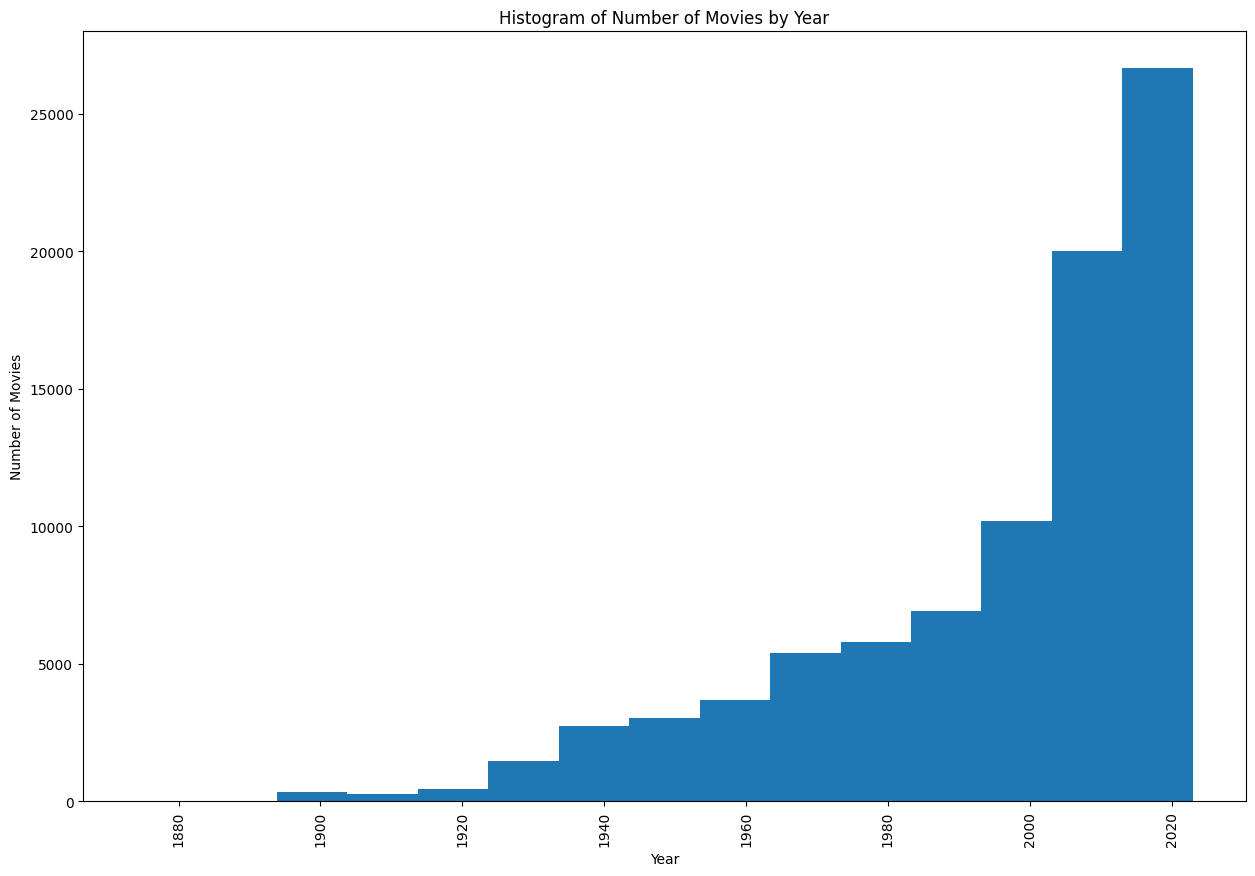

In [14]:
artifacts_dir = PROJECT_ROOT / paths['artifacts_dir']
notebook_artifacts_dir = artifacts_dir / paths['notebooks_artifacts_dir']
hist_movie_year_plot_path = notebook_artifacts_dir / paths['hist_movie_year_plot']
hist_movie_year_plot_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(15, 10))
ax.hist(movies.loc[~movies['year'].isna(), 'year'], bins=decs)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Histogram of Number of Movies by Year')
ax.set_ylabel('Number of Movies')
ax.set_xlabel('Year')
plt.savefig(hist_movie_year_plot_path)
plt.show()

The movie release year was extracted into a separate field. The histogram of movie counts by release year shows that over time, the number of movies users interact with increases. This is presumably related to the growth of movie production.

Total unique users: 200,948, unique movies: 87,585.